In [1]:
import os
import cv2 as cv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import tensorflow as tf
import mediapipe as mp
import optuna
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay,classification_report,roc_auc_score

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam,SGD
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

c:\Users\prema\Desktop\ASL\sign\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Dataset Path

DATASET_PATH = "dataset_updated"

classes = sorted(os.listdir(DATASET_PATH))

print("Classes Found:",classes)
print("Number of Classes:", len(classes))

Classes Found: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Number of Classes: 26


In [3]:
# Reading all the Image Paths with labels

data = []

for label in classes:

    class_folder = os.path.join(DATASET_PATH, label)

    if not os.path.join(class_folder):
        continue
    else:

        for fname in os.listdir(class_folder):
            if fname.lower().endswith((".jpg", ".png", ".jpeg")):

                data.append({"filepath": os.path.join(class_folder, fname), "label": label})

df = pd.DataFrame(data)

df.sample(20)

,filepath,label
24357,dataset_updated\Y\Y1925.jpg,Y
18554,dataset_updated\S\S2470.jpg,S
7618,dataset_updated\H\H2612.jpg,H
9799,dataset_updated\J\J409.jpg,J
8391,dataset_updated\I\I2009.jpg,I
18400,dataset_updated\S\S2022.jpg,S
8244,dataset_updated\I\I1647.jpg,I
24292,dataset_updated\Y\Y1792.jpg,Y
2258,dataset_updated\C\C170.jpg,C
8234,dataset_updated\I\I1610.jpg,I


In [4]:
# Total number of images

print("Total Number of Images:", len(df))

Total Number of Images: 26000


In [5]:
# Class Distribution

print("Class Distribution:", df['label'].value_counts())

Class Distribution: label
A    1000
B    1000
C    1000
D    1000
E    1000
F    1000
G    1000
H    1000
I    1000
J    1000
K    1000
L    1000
M    1000
N    1000
O    1000
P    1000
Q    1000
R    1000
S    1000
T    1000
U    1000
V    1000
W    1000
X    1000
Y    1000
Z    1000
Name: count, dtype: int64


* The dataset is well balanced

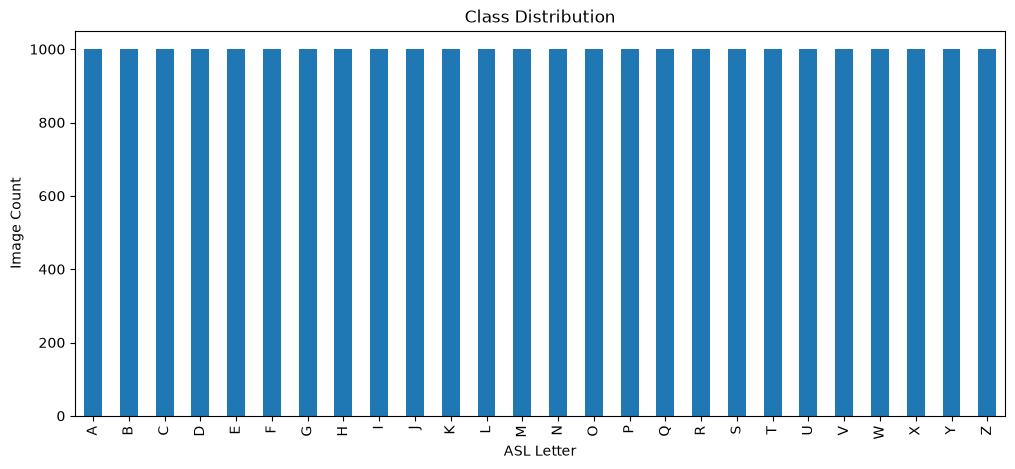

In [6]:
# Visual Representation of the class distribution

df["label"].value_counts().sort_index().plot(kind="bar", figsize=(12, 5))
plt.title("Class Distribution")
plt.xlabel("ASL Letter")
plt.ylabel("Image Count")
plt.show()

In [7]:
# Checking for corrupt images

corrupted = []

for path in df["filepath"]:

    img = cv.imread(path)

    if img is None:
        corrupted.append(path)

print("Number of corrupt Images:", len(corrupted))

Number of corrupt Images: 0


* There are no corrupt images in the dataset

In [8]:
# Checking the dimensions of images in the dataset

dimensions = []

for path in df['filepath']:

    img = cv.imread(path)

    if img is not None:

        dimensions.append(img.shape)

dimensions = set(dimensions)

print("Image Dimensions:", dimensions)
print("Number of unique Dimensions:", len(dimensions))

Image Dimensions: {(200, 200, 3)}
Number of unique Dimensions: 1


* All of the images contain 200x200 pixels and 3 color channels

# Exploratory Data Analysis 

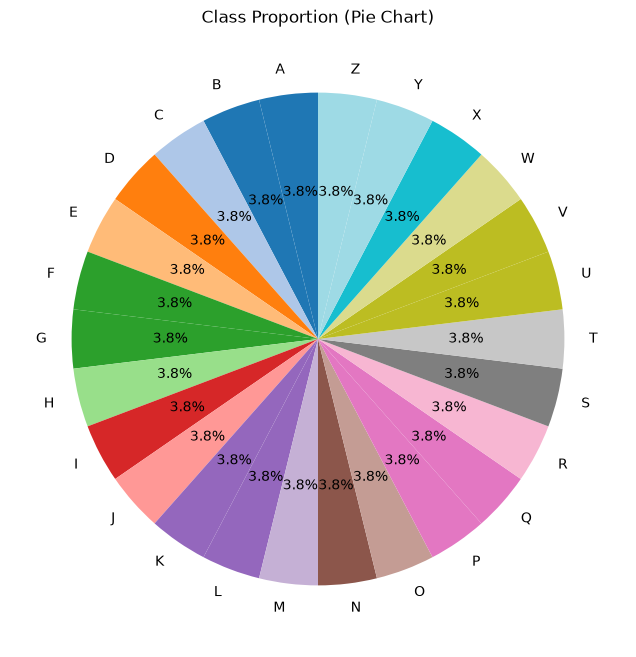

In [9]:
# Pie Chart of all Labels

plt.figure(figsize=(8, 8))
df["label"].value_counts().sort_index().plot(
    kind="pie", autopct="%1.1f%%", startangle=90, cmap="tab20"
)
plt.title("Class Proportion (Pie Chart)")
plt.ylabel("")
plt.show()

* The data is well distributed

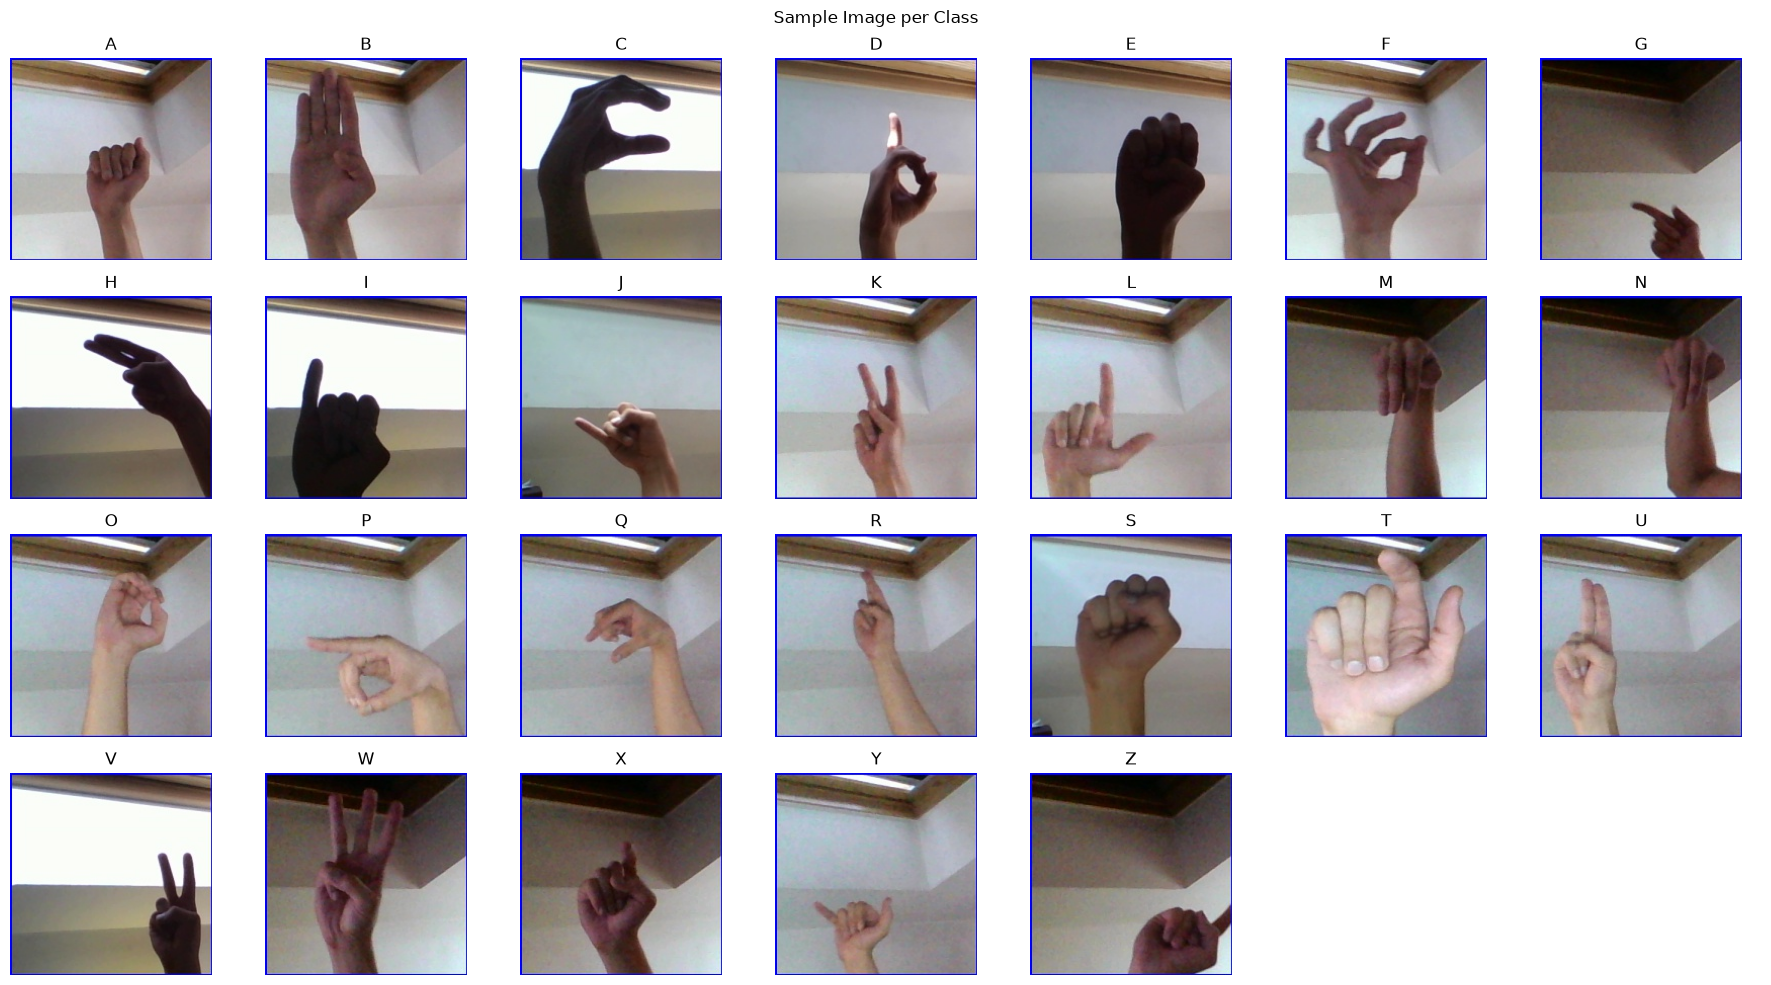

In [10]:
# Sample Images per class

fig, axes = plt.subplots(4, 7, figsize=(18, 10))
sample_classes = classes[:26]  # A-Z
for ax, label in zip(axes.flatten(), sample_classes):
    class_folder = os.path.join(DATASET_PATH, label)
    sample_file = random.choice(os.listdir(class_folder))
    img = cv.imread(os.path.join(class_folder, sample_file))
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(label)
    ax.axis("off")

for ax in axes.flatten()[len(sample_classes):]:
    ax.axis("off")
plt.suptitle("Sample Image per Class")
plt.tight_layout()
plt.show()

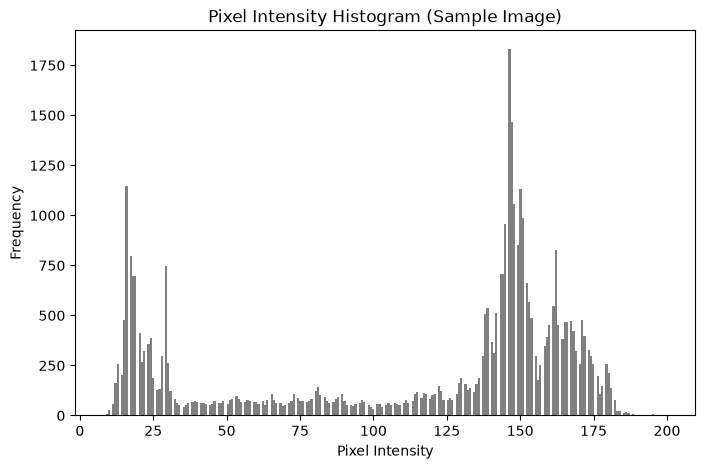

In [11]:
sample_img = cv.imread(df.iloc[0]["filepath"], cv.IMREAD_GRAYSCALE)
plt.figure(figsize=(8, 5))
plt.hist(sample_img.ravel(), bins=256, color="gray")
plt.title("Pixel Intensity Histogram (Sample Image)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

# Preprocessing

In [12]:
# Checking shape of images

img = cv.imread(df['filepath'][0])

img.shape

(200, 200, 3)

* As I checked before all the images 200x200 and have 3 color channels i am keeping the size as it is so i wont lose any image details by shrinking images

### Normalization

* The image normalization step was considered during preprocessing. Since MediaPipe Hand Landmarker expects the original image pixel values for accurate landmark detection, the images were retained in their original uint8 format (pixel range 0–255) during feature extraction. After extracting the hand landmark coordinates, the resulting numerical features were prepared for model training.

### Image Agumentation

In [13]:
# Creating the Agumentation object

train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest"
)

# Feature Extraction

In [14]:
# Creating the HandLandmarker

base_options = python.BaseOptions(
    model_asset_path = r"models\hand_landmarker.task"
)

options = vision.HandLandmarkerOptions(
    base_options = base_options,
    num_hands = 1
)

detector = vision.HandLandmarker.create_from_options(options)

* The dataset was split into training and testing subsets before augmentation to prevent data leakage. Since augmented samples are generated from the original images, performing augmentation before splitting could result in highly similar samples appearing in both training and testing sets, leading to an overly optimistic evaluation.

### train_test_split

In [15]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print(train_df.shape)
print(test_df.shape)
print(train_df["label"].value_counts())
print(test_df["label"].value_counts())

(20800, 2)
(5200, 2)
label
Z    800
Y    800
H    800
J    800
V    800
A    800
B    800
F    800
M    800
L    800
Q    800
W    800
P    800
I    800
C    800
O    800
N    800
X    800
U    800
S    800
D    800
T    800
R    800
K    800
G    800
E    800
Name: count, dtype: int64
label
P    200
U    200
B    200
Q    200
Y    200
Z    200
M    200
H    200
O    200
W    200
X    200
K    200
A    200
S    200
E    200
T    200
G    200
R    200
N    200
F    200
C    200
L    200
I    200
J    200
V    200
D    200
Name: count, dtype: int64


In [16]:
def landmark_normalization(result):
    
    feature = []
    landmarks = result.hand_landmarks[0]

    wrist = landmarks[0]
    middle_base = landmarks[9]

    scale = np.sqrt((wrist.x - middle_base.x)**2 + (wrist.y - middle_base.y)**2 + (wrist.z - middle_base.z)**2)
    
    for landmark in result.hand_landmarks[0]:

        landmark.x = landmark.x - wrist.x
        landmark.y = landmark.y - wrist.y
        landmark.z = landmark.z - wrist.z

        landmark.x = landmark.x / scale
        landmark.y = landmark.y / scale
        landmark.z = landmark.z / scale

        feature.extend([
            landmark.x,
            landmark.y,
            landmark.z
        ])

    return feature
    

In [17]:

def extract_features(dataframe, augment=False):

    features = []
    labels = []
    sources = []
    detected = []

    for f, l in zip(dataframe["filepath"], dataframe["label"]):

        img = cv.imread(f)

        if img is None:
            continue

        img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)


        # ================= Original Image =================

        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=img_rgb
        )

        result = detector.detect(mp_image)


        if result.hand_landmarks:

            feature = landmark_normalization(result)

            if feature is not None:
                features.append(feature)
                labels.append(l)
                sources.append("Original")
                detected.append(True)
            else:
                features.append([np.nan]*63)
                labels.append(l)
                sources.append("Original")
                detected.append(False)

        else:

            features.append([np.nan]*63)
            labels.append(l)
            sources.append("Original")
            detected.append(False)



        # ================= Augmented Image =================

        if augment:

            aug_img = next(
                train_datagen.flow(
                    np.expand_dims(img_rgb, axis=0),
                    batch_size=1,
                    shuffle=False
                )
            )[0].astype(np.uint8)


            mp_aug = mp.Image(
                image_format=mp.ImageFormat.SRGB,
                data=aug_img
            )


            result_aug = detector.detect(mp_aug)


            if result_aug.hand_landmarks:

                feature = landmark_normalization(result_aug)

                if feature is not None:

                    features.append(feature)
                    labels.append(l)
                    sources.append("Augmented")
                    detected.append(True)

                else:
                    features.append([np.nan]*63)
                    labels.append(l)
                    sources.append("Augmented")
                    detected.append(False)

            else:

                features.append([np.nan]*63)
                labels.append(l)
                sources.append("Augmented")
                detected.append(False)


    return features, labels, sources, detected

In [18]:
X_train, y_train, train_source, train_detected = extract_features(
    train_df,
    augment=True
)

In [19]:
print("Number of samples:", len(X_train))
print("Number of labels:", len(y_train))

Number of samples: 41600
Number of labels: 41600


In [20]:
print(
    pd.Series(train_detected).value_counts()
)

True     32107
False     9493
Name: count, dtype: int64


In [21]:
train_check = pd.DataFrame({
    "source": train_source,
    "detected": train_detected,
    "label": y_train
})

print(pd.crosstab(
    train_check["source"],
    train_check["detected"]
))

detected   False  True 
source                 
Augmented   4724  16076
Original    4769  16031


In [22]:
X_test, y_test, test_source, test_detected = extract_features(
    test_df,
    augment=False
)

In [23]:
print("Number of test samples:", len(X_test))
print(pd.Series(test_detected).value_counts())

Number of test samples: 5200
True     3974
False    1226
Name: count, dtype: int64


In [24]:
# Training dataframe
train_features_df = pd.DataFrame(X_train)
train_features_df["label"] = y_train
train_features_df["source"] = train_source
train_features_df["detected"] = train_detected


# Testing dataframe
test_features_df = pd.DataFrame(X_test)
test_features_df["label"] = y_test
test_features_df["source"] = test_source
test_features_df["detected"] = test_detected

In [25]:
train_features_df = train_features_df[
    train_features_df["detected"] == True
]

test_features_df = test_features_df[
    test_features_df["detected"] == True
]

In [26]:
print(train_features_df.shape)
print(test_features_df.shape)

(32107, 66)
(3974, 66)


In [27]:
# Remove extra columns and separate input/output

X_train = train_features_df.drop(
    columns=["label", "source", "detected"]
)

y_train = train_features_df["label"]


X_test = test_features_df.drop(
    columns=["label", "source", "detected"]
)

y_test = test_features_df["label"]

In [28]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(32107, 63)
(32107,)
(3974, 63)
(3974,)


In [29]:
encoder = LabelEncoder()

y_train = encoder.fit_transform(y_train)

y_test = encoder.transform(y_test)

In [30]:
print(y_train[:10])
print(encoder.classes_)

[24 24  7  7  9  9 21 21  0  0]
['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']


In [31]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [32]:
print(X_train.shape)
print(type(X_train))
print(X_test.shape)
print(type(X_test))

print(X_train.mean())
print(X_train.std())

(32107, 63)
<class 'numpy.ndarray'>
(3974, 63)
<class 'numpy.ndarray'>
3.2528266016946943e-18
0.9759000729485332


# Model building

In [33]:
# Lets first build a baseline model

ann_model = Sequential()

ann_model.add(
    Dense(
        128,
        activation= 'relu',
        input_shape = (X_train.shape[1],)
    )
)
ann_model.add(Dropout(0.3))
ann_model.add(
    Dense(
        64,
        activation= 'relu'
    )
)
ann_model.add(Dropout(0.2))
ann_model.add(
    Dense(
        26,
        activation= 'softmax'
    )
)

ann_model.summary()

c:\Users\prema\Desktop\ASL\sign\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,138 (70.85 KB)

 Trainable params: 18,138 (70.85 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Compile the base model

ann_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

# Early Stopping

early_stop = EarlyStopping(
    monitor= 'val_loss',
    patience= 10,
    restore_best_weights= True
)

In [35]:
# Training the base model

history = ann_model.fit(

    X_train,
    y_train,

    validation_split = 0.2,
    epochs = 100,
    batch_size = 32,
    callbacks = [early_stop],
    verbose = 1
)

Epoch 1/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6139 - loss: 1.3350 - val_accuracy: 0.8877 - val_loss: 0.4299
Epoch 2/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8523 - loss: 0.4739 - val_accuracy: 0.9248 - val_loss: 0.2878
Epoch 3/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8914 - loss: 0.3561 - val_accuracy: 0.9287 - val_loss: 0.2507
Epoch 4/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9088 - loss: 0.3005 - val_accuracy: 0.9288 - val_loss: 0.2376
Epoch 5/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9199 - loss: 0.2675 - val_accuracy: 0.9444 - val_loss: 0.1933
Epoch 6/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9247 - loss: 0.2518 - val_accuracy: 0.9369 - val_loss: 0.1967
Epoch 7/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9289 - loss: 0.2305 - val_accuracy: 0.9534 - val_loss: 0.1701
Epoch 8/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9325 - loss: 0.2222 - val_accu

In [36]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [37]:
print(f"Training Accuracy   : {history.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy : {history.history['val_accuracy'][-1]:.4f}")

print(f"Training Loss       : {history.history['loss'][-1]:.4f}")
print(f"Validation Loss     : {history.history['val_loss'][-1]:.4f}")

Training Accuracy   : 0.9588
Validation Accuracy : 0.9664
Training Loss       : 0.1308
Validation Loss     : 0.1121


# Hyperparameter Tuning

In [38]:
def objective(trial):

    # Hyperparameters

    units_1 = trial.suggest_int(
        "units_1",
        64,
        256,
        step = 32
    )

    dropout_1 = trial.suggest_float(
        "dropout_1",
        0.2,
        0.5
    )

    units_2 = trial.suggest_int(
        "units_2",
        32,
        128,
        step = 32
    )

    dropout_2 = trial.suggest_float(
        "dropout_2",
        0.2,
        0.5
    )

    optimizer_name = trial.suggest_categorical(
        "optimizer",
        ["Adam","SGD"]
    )

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-4,
        1e-2,
        log = True
    )

    # Selecting Optimizer

    if optimizer_name == "Adam":
        optimizer = Adam(learning_rate = learning_rate)

    else:
        optimizer = SGD(learning_rate = learning_rate)


    # Model Building

    model = Sequential()

    model.add(tf.keras.layers.Input(shape=(X_train.shape[1],)))

    model.add(
        Dense(
            units= units_1,
            activation= 'relu'
        )
    )

    model.add(Dropout(dropout_1))

    model.add(
        Dense(
            units = units_2,
            activation= 'relu'
        )
    )

    model.add(Dropout(dropout_2))

    model.add(
        Dense(
            26,
            activation= 'softmax'
        )
    )

    # Compile the Model

    model.compile(
        optimizer = optimizer,
        loss = "sparse_categorical_crossentropy",
        metrics = ['accuracy']
    )

    # Early Stopping
    early_stop = EarlyStopping(
        monitor= "val_loss",
        patience= 5,
        restore_best_weights= True
    )


    # Train the model

    history = model.fit(
        X_train,
        y_train,

        validation_split = 0.2,
        epochs = 50,
        batch_size = 32,
        callbacks = [early_stop],
        verbose = 0
    )

    return max(history.history["val_accuracy"])

In [39]:
study = optuna.create_study(
    direction="maximize"
)

[I 2026-08-08 13:19:43,870] A new study created in memory with name: no-name-1143a26e-e297-4b9a-aa41-bfb74dc64539


In [40]:
study.optimize(
    objective,
    n_trials= 50
)

[I 2026-08-08 13:22:34,629] Trial 0 finished with value: 0.959202766418457 and parameters: {'units_1': 96, 'dropout_1': 0.27186978567306597, 'units_2': 32, 'dropout_2': 0.37428936778899885, 'optimizer': 'Adam', 'learning_rate': 0.0003861348130641482}. Best is trial 0 with value: 0.959202766418457.
[I 2026-08-08 13:23:30,098] Trial 1 finished with value: 0.933976948261261 and parameters: {'units_1': 224, 'dropout_1': 0.23174678744299776, 'units_2': 64, 'dropout_2': 0.34154527045005545, 'optimizer': 'Adam', 'learning_rate': 0.00411017016443945}. Best is trial 0 with value: 0.959202766418457.
[I 2026-08-08 13:24:48,421] Trial 2 finished with value: 0.9520398378372192 and parameters: {'units_1': 192, 'dropout_1': 0.45314991560562945, 'units_2': 96, 'dropout_2': 0.24702338427164186, 'optimizer': 'Adam', 'learning_rate': 0.002564727579714211}. Best is trial 0 with value: 0.959202766418457.
[I 2026-08-08 13:27:42,427] Trial 3 finished with value: 0.8836811184883118 and parameters: {'units_1':

In [41]:
print("Best Accuracy:", study.best_value)
print("best_params:", study.best_params)

Best Accuracy: 0.9757084846496582
best_params: {'units_1': 256, 'dropout_1': 0.2033916510625386, 'units_2': 96, 'dropout_2': 0.20072469991850703, 'optimizer': 'Adam', 'learning_rate': 0.0002717861655858727}


In [42]:
units_1, dropout_1, units_2, dropout_2, optimizer, learning_rate = study.best_params.values()

In [43]:
final_ann = Sequential()

final_ann.add(tf.keras.layers.Input(shape=(X_train.shape[1],)))

final_ann.add(
    Dense(
        units= units_1,
        activation= "relu"
    )
)

final_ann.add(Dropout(dropout_1))

final_ann.add(
    Dense(
        units= units_2,
        activation= 'relu'
    )
)

final_ann.add(Dropout(dropout_2))

final_ann.add(
    Dense(
        26,
        activation= "softmax"
    )
)

optimizer = Adam(learning_rate= learning_rate)

final_ann.compile(
    optimizer = optimizer,
    loss = "sparse_categorical_crossentropy",
    metrics = ['accuracy']
)


final_ann.summary()


Model: "sequential_51"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_153 (Dense)               │ (None, 256)            │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_102 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_154 (Dense)               │ (None, 96)             │        24,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_103 (Dropout)           │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_155 (Dense)               │ (None, 26)             │         2,522 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,578 (170.23 KB)

 Trainable params: 43,578 (170.23 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
early_stop = EarlyStopping(
    monitor= "val_loss",
    patience= 10,
    restore_best_weights= True
)

In [45]:
history_final = final_ann.fit(
    X_train,
    y_train,

    validation_split = 0.2,
    epochs = 100,
    batch_size = 32,
    callbacks = [early_stop],
    verbose =1
)

Epoch 1/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4901 - loss: 1.8448 - val_accuracy: 0.8388 - val_loss: 0.7729
Epoch 2/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8140 - loss: 0.6584 - val_accuracy: 0.9017 - val_loss: 0.4064
Epoch 3/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8767 - loss: 0.4268 - val_accuracy: 0.9248 - val_loss: 0.3045
Epoch 4/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9021 - loss: 0.3375 - val_accuracy: 0.9298 - val_loss: 0.2568
Epoch 5/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9180 - loss: 0.2828 - val_accuracy: 0.9438 - val_loss: 0.2197
Epoch 6/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9266 - loss: 0.2485 - val_accuracy: 0.9464 - val_loss: 0.2016
Epoch 7/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9350 - loss: 0.2235 - val_accuracy: 0.9427 - val_loss: 0.1956
Epoch 8/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9401 - loss: 0.2091 - val_accu

# Model Evaluation

In [46]:
# Accuracy

test_loss, test_accuracy = final_ann.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

Test Loss     : 0.0504
Test Accuracy : 0.9859


In [47]:
# Predictions
y_pred_prob = final_ann.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis= 1)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


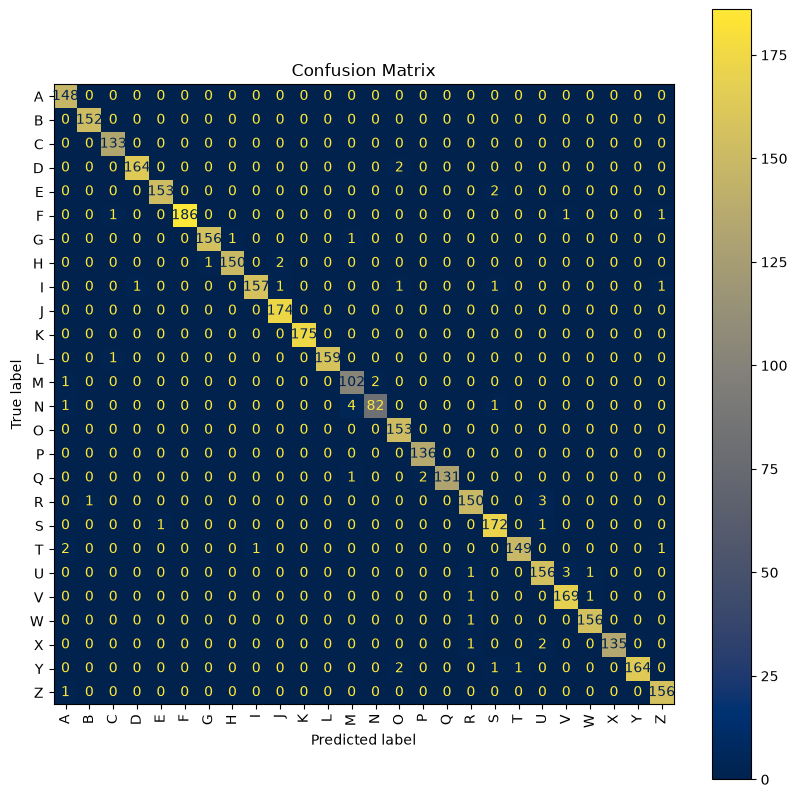

In [48]:

cm = confusion_matrix(
    y_test,
    y_pred
)


labels = encoder.classes_

fig, ax = plt.subplots(figsize=(10,10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    cmap="cividis",
    xticks_rotation=90,
    ax=ax,
    values_format="d"
)

plt.title("Confusion Matrix")
plt.show()

In [49]:
print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))

              precision    recall  f1-score   support

           A       0.97      1.00      0.98       148
           B       0.99      1.00      1.00       152
           C       0.99      1.00      0.99       133
           D       0.99      0.99      0.99       166
           E       0.99      0.99      0.99       155
           F       1.00      0.98      0.99       189
           G       0.99      0.99      0.99       158
           H       0.99      0.98      0.99       153
           I       0.99      0.97      0.98       162
           J       0.98      1.00      0.99       174
           K       1.00      1.00      1.00       175
           L       1.00      0.99      1.00       160
           M       0.94      0.97      0.96       105
           N       0.98      0.93      0.95        88
           O       0.97      1.00      0.98       153
           P       0.99      1.00      0.99       136
           Q       1.00      0.98      0.99       134
           R       0.97    

In [50]:
roc_auc = roc_auc_score(
    y_test,
    y_pred_prob,          # the softmax probabilities you already have
    multi_class="ovr",    # one-vs-rest
    average="macro"       # unweighted mean across all 26 classes
)
print(f"Macro ROC-AUC: {roc_auc:.4f}")

Macro ROC-AUC: 0.9999


# Model Saving

In [51]:
# Saving Final Model
final_ann.save(r"models\final_ann_new.keras")
# Saving Label Encoder
joblib.dump(encoder, r"models\label_encoder_new.pkl")
# Saving Scaler
joblib.dump(scaler, r"models\scaler_new.pkl")

print("All models Saved Successfully")

All models Saved Successfully
